## **Machine Learning Aplicado a las Finanzas** 🚀
### **Sesión 10: Interpretabilidad (SHAP/Drift)**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import spearmanr
import xgboost as xgb
import shap
import warnings

sns.set_style("dark")
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.float_format", "{:.4f}".format)

## 🎯 **`Motivación: De la Predicción a la Explicación`**

En la sesión 9 comparamos `Weight`, `Gain` y `Cover` como medidas de importancia de features para XGBoost; todas agregadas sobre el modelo completo, ninguna capaz de explicar *una predicción individual*, y ninguna acompañada de una noción de qué tan estables son esas importancias en el tiempo. Esta sesión cierra esas tres brechas:

1. **Explicación global y local con SHAP**, un único marco teórico (valores de Shapley) que unifica *qué features importan en general* con *por qué el modelo predijo esto para esta observación puntual*.

2. **Diagnóstico de riesgo de modelo**, más allá del AUC de test, ¿qué tan estable es la distribución de los features de entrada (*data drift*), la relación feature-target (*concept drift*), y el propio ranking de importancia en el tiempo?
   
3. **Gobernanza** — cómo documentar un modelo y definir un plan de monitoreo, en línea con marcos de *model risk management* como el SR 11-7 (Fed/OCC), que exige desarrollo, validación independiente y monitoreo continuo como pilares separados.

Un modelo con buen AUC en test pero sin estas tres capas es, desde la óptica de riesgo, un modelo no gobernable: nadie puede explicar una decisión puntual, nadie sabe cuándo dejó de ser válido, y nadie puede auditar si sigue confiando en las mismas variables que cuando se validó.

Esto no es un ejercicio artificial: SHAP, PSI y el monitoreo de model risk se originaron y se usan de forma más intensiva precisamente en la industria de scoring crediticio, bajo el marco regulatorio SR 11-7 (Fed/OCC) mencionado en la sesión 10. Un scorecard de crédito que decide otorgar o denegar financiamiento necesita, por ley en muchas jurisdicciones (p. ej. *adverse action notices* bajo ECOA en EE.UU.), poder explicar **por qué** se rechazó a un solicitante puntual; exactamente el rol del waterfall plot de SHAP.

## 🔧 **`Datos y Modelo Base`**

Reutilizamos el dataset `Bankloan.csv` (sesión 2) con el mismo pipeline de limpieza ya usado en `MLCreditScoring.ipynb`: se reemplaza el valor centinela `999999` en `Leverage` por `NaN`, se imputan los `NaN` restantes con la mediana, y se descartan outliers extremos (`Income < 300`, `Creddebt < 15`, `OthDebt < 30`). También agregamos `OthDebtRatio = OthDebt / Income`, la misma variable derivada introducida en la sección de WOE de la sesión 2.

`Education` se codifica ordinalmente (1 = Básica, 2 = Media, 3 = Superior incompleta, 4 = Superior completa, 5 = Posgrado), en línea con la definición de la variable en la sesión 2. El target es `Default` (1 = el cliente cayó en incumplimiento).

Ordenamos el dataframe por `customer` (proxy de orden de originación) y aplicamos el mismo split 70/15/15 respetando ese orden — el análogo exacto del split temporal train/val/test del notebook original, ahora sobre "cohortes de originación" en vez de fechas de trading.

In [2]:
DATA_PATH = "../clase_02/data_raw/Bankloan.csv"

raw = pd.read_csv(DATA_PATH)

raw.Leverage.values[raw.Leverage.values == 999999] = np.nan
raw.fillna(raw.median(numeric_only=True), inplace=True)
raw = raw.loc[(raw["Income"] < 300) & (raw["Creddebt"] < 15) & (raw["OthDebt"] < 30)]

EDU_MAP = {"Bas": 1, "Med": 2, "SupInc": 3, "SupCom": 4, "Posg": 5}
raw["Education"] = raw["Education"].map(EDU_MAP)
raw["OthDebtRatio"] = raw["OthDebt"] / raw["Income"]

feat = raw.sort_values("customer").reset_index(drop=True)   # proxy de orden de originación

FEATURES = ["Age", "Education", "Employ", "Address", "Income", "Leverage",
            "Creddebt", "OthDebt", "MonthlyLoad", "OthDebtRatio"]

X_df = feat[FEATURES].astype(float)
y = feat["Default"].values

split_tr = int(len(feat) * 0.70)
split_va = int(len(feat) * 0.85)
X_train, X_val, X_test = X_df.iloc[:split_tr], X_df.iloc[split_tr:split_va], X_df.iloc[split_va:]
y_train, y_val, y_test = y[:split_tr], y[split_tr:split_va], y[split_va:]

print(f"Bankloan: {feat.shape[0]} obs | {len(FEATURES)} features")
print(f"Train: {len(y_train)} obs | Val: {len(y_val)} obs | Test: {len(y_test)} obs")
print(f"Tasa de default — train: {y_train.mean():.2%} | val: {y_val.mean():.2%} | test: {y_test.mean():.2%}")

Bankloan: 1466 obs | 10 features
Train: 1026 obs | Val: 220 obs | Test: 220 obs
Tasa de default — train: 37.43% | val: 33.18% | test: 34.55%


In [3]:
xgb_clf = xgb.XGBClassifier(
    n_estimators = 1000,
    learning_rate = 0.03,
    max_depth = 3,
    subsample = 0.8,
    colsample_bytree = 0.8,
    reg_lambda = 1.0,
    eval_metric = "auc",
    early_stopping_rounds = 50,
    random_state = 42)

xgb_clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

test_auc = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1])
print(f"XGBoost detuvo en la ronda: {xgb_clf.best_iteration}")
print(f"AUC en test: {test_auc:.4f}")

XGBoost detuvo en la ronda: 99
AUC en test: 0.8191


## 🔎 **`SHAP: Fundamento Teórico — Valores de Shapley`**

SHAP (**SH**apley **A**dditive ex**P**lanations, Lundberg & Lee, 2017) adapta un concepto de teoría de juegos cooperativos a la explicación de modelos. La pregunta que responde: *si las features de un solicitante (edad, ingreso, apalancamiento, antigüedad laboral, etc.) son "jugadores" que cooperan para producir una predicción de riesgo, cuánto le corresponde a cada una del "pago" total*.

Formalmente, el valor de Shapley de la feature $i$ para una observación $x$ es el promedio de su contribución marginal sobre **todas las posibles coaliciones** (subconjuntos) de las demás features:

$$\phi_i(x) = \sum_{S \subseteq \{1,\ldots,p\} \setminus \{i\}} \frac{|S|!\,(p-|S|-1)!}{p!} \Big[f_x(S \cup \{i\}) - f_x(S)\Big]$$

donde $f_x(S)$ es la predicción esperada del modelo usando solo el subconjunto de features $S$ (las demás se marginalizan). Esto garantiza una propiedad clave, la **aditividad**:

$$f(x) = \phi_0 + \sum_{i=1}^{p} \phi_i(x)$$

es decir, la predicción para $x$ se descompone exactamente en un valor base $\phi_0$ (la predicción esperada del modelo sin ninguna información, $\mathbb{E}[f(X)]$) más la contribución de cada feature sin residuo. Calcular esto exactamente por fuerza bruta es exponencial en $p$ (hay que evaluar $2^p$ coaliciones), pero para modelos de árboles, el algoritmo **TreeSHAP** (Lundberg et al., 2020) explota la estructura del árbol para calcularlo en tiempo polinomial — es exacto, no una aproximación, y es lo que usa `shap.TreeExplainer` para XGBoost/LightGBM/Random Forest.

In [4]:
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer(X_test)   # objeto shap.Explanation: .values, .base_values, .data

margin_pred = xgb_clf.predict(X_test, output_margin=True)
reconstructed = shap_values.base_values + shap_values.values.sum(axis=1)
max_abs_diff = np.max(np.abs(margin_pred - reconstructed))

print(f"Valor base (phi_0, log-odds promedio): {shap_values.base_values[0]:.4f}")
print(f"Máxima diferencia |predicción - (phi_0 + suma phi_i)|: {max_abs_diff:.2e}")

Valor base (phi_0, log-odds promedio): -0.5152
Máxima diferencia |predicción - (phi_0 + suma phi_i)|: 7.15e-07


**Interpretación:** la diferencia máxima entre la predicción real del modelo (en escala log-odds, antes de la sigmoide) y la reconstrucción $\phi_0 + \sum_i \phi_i(x)$ es del orden de $10^{-6}$ o menor — esencialmente cero, salvo error numérico de punto flotante. Igual que en el notebook de la sesión 10, esto confirma la propiedad de aditividad: cada $\phi_i(x)$ es literalmente una porción de la predicción de riesgo del solicitante, no una medida de importancia heurística. Esa propiedad es lo que permite sumar, comparar y visualizar contribuciones de forma consistente tanto a nivel global como para una solicitud individual.

## 📊 **`Importancia Global: SHAP Summary Plot vs Gain`**

El *summary plot* (o *beeswarm*) grafica, para cada feature, la distribución completa de $\phi_i(x)$ sobre todas las observaciones de test: cada punto es un solicitante, su posición horizontal es el valor SHAP (impacto en la predicción de default), y su color codifica si el valor original del feature era alto o bajo. Esto revela no solo *qué tan importante* es un feature en promedio (como `Gain`), sino también la **dirección** del efecto (¿valores altos del feature empujan la predicción hacia mayor o menor riesgo?) y su **heterogeneidad** — información que un solo número de `Gain` no puede transmitir.

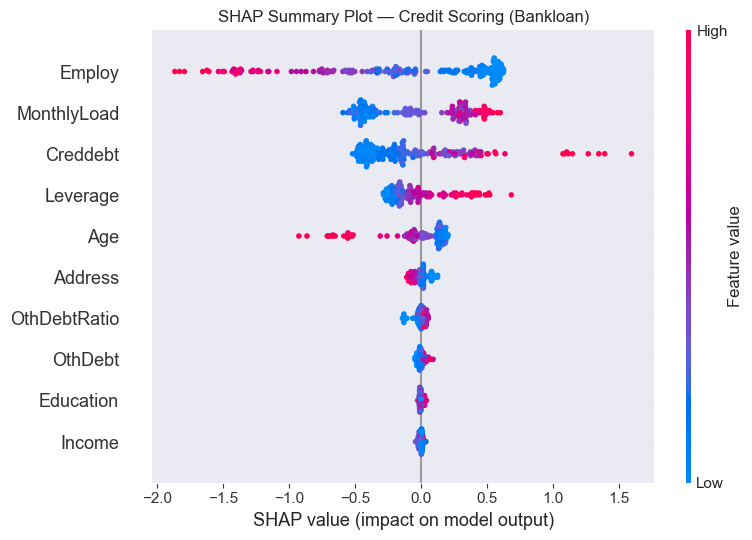

              mean|SHAP|    Gain  rank_SHAP  rank_Gain
Employ            0.5704  9.7451     1.0000     2.0000
MonthlyLoad       0.3511 19.0395     2.0000     1.0000
Creddebt          0.3309  6.7118     3.0000     5.0000
Leverage          0.1837  7.8313     4.0000     3.0000
Age               0.1657  6.9769     5.0000     4.0000
Address           0.0406  4.3565     6.0000     6.0000
OthDebtRatio      0.0237  3.0948     7.0000     7.0000
OthDebt           0.0156  2.9027     8.0000    10.0000
Education         0.0094  2.9365     9.0000     9.0000
Income            0.0089  2.9928    10.0000     8.0000

Correlación de rangos (Spearman) SHAP vs Gain: 0.903


In [5]:
fig = plt.figure(figsize=(9, 5.5))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot — Credit Scoring (Bankloan)", fontsize=12)
plt.tight_layout()
plt.show()

mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=FEATURES, name="mean|SHAP|")
gain_imp = pd.Series(
    xgb_clf.get_booster().get_score(importance_type="gain"), name="Gain"
).reindex(FEATURES).fillna(0.0)

rank_shap = mean_abs_shap.rank(ascending=False)
rank_gain = gain_imp.rank(ascending=False)
rho, _ = spearmanr(rank_shap, rank_gain)

comparison = pd.DataFrame({"mean|SHAP|": mean_abs_shap, "Gain": gain_imp,
                            "rank_SHAP": rank_shap, "rank_Gain": rank_gain})
print(comparison.sort_values("mean|SHAP|", ascending=False).round(4))
print(f"\nCorrelación de rangos (Spearman) SHAP vs Gain: {rho:.3f}")

**Interpretación**

En el beeswarm cada punto es un solicitante de test; el color indica si su valor en esa feature era alto (rojo) o bajo (azul), y la posición horizontal es cuánto empujó esa feature la predicción en escala log-odds (derecha = más riesgo, izquierda = menos riesgo). Ordenando por `mean|SHAP|` (magnitud promedio del efecto), la tabla `comparison` y el gráfico muestran dos grupos claramente separados:

**Grupo 1 — features que realmente mueven la predicción:**

| Feature | mean\|SHAP\| | Dirección en el beeswarm | Lectura económica |
|---|---|---|---|
| `Employ` (años en el trabajo actual) | 0.570 (la más alta) | rojo (alto) a la **izquierda**, azul (bajo) a la **derecha** — corr(feature, SHAP) ≈ −0.94 | Es la variable **protectora** más fuerte del modelo: a mayor antigüedad laboral, menor riesgo predicho. Un solicitante con poca antigüedad puede ver su log-odds subir hasta +0.6, y uno muy senior bajarlo hasta −1.9 — el rango de esta única feature es mayor que el de cualquier otra. |
| `MonthlyLoad` (carga mensual de deuda/ingreso) | 0.351 | rojo a la **derecha**, azul a la **izquierda** — corr ≈ +0.82 | Segunda en importancia y de **riesgo**: mayor carga mensual empuja hacia mayor probabilidad de default, coherente con una capacidad de pago comprometida. |
| `Creddebt` (deuda de tarjeta de crédito) | 0.331 | Mayoría rojo/azul mezclado cerca de cero, pero con **una cola de puntos rosados aislados muy a la derecha** (hasta +1.6) — corr ≈ +0.93 | De riesgo: el efecto típico es moderado, pero un pequeño grupo de solicitantes con deuda de tarjeta extrema recibe un empujón de riesgo desproporcionado — el modelo los trata como casos atípicos de alto riesgo, no solo "un poco más de deuda". |
| `Leverage` (deuda total / ingreso) | 0.184 | rojo a la derecha, azul a la izquierda — corr ≈ +0.93 | De riesgo, dirección limpia y monotónica: a mayor apalancamiento, mayor riesgo, sin sorpresas. |
| `Age` (edad) | 0.166 | rojo (edad alta) a la **izquierda**, azul (edad baja) a la **derecha** — corr ≈ −0.92 | Protectora: clientes de mayor edad son vistos como menos riesgosos. Nótese que su dirección es casi un espejo de `Employ` — es esperable que estén correlacionadas (a mayor edad, más años posibles de antigüedad laboral), lo que sugiere que parte de su señal podría ser redundante con `Employ` en vez de aportar información nueva. |

**Grupo 2 — features que el modelo prácticamente no usa (mean\|SHAP\| < 0.05, casi pegadas a la línea vertical de cero en el gráfico):**

| Feature | mean\|SHAP\| | Dirección | Por qué pesa tan poco |
|---|---|---|---|
| `Address` (años en la dirección actual) | 0.041 | Protectora débil (corr ≈ −0.85, pero rango angosto: [−0.11, 0.13]) | La dirección es consistente (más estabilidad domiciliaria, menos riesgo) pero la magnitud es marginal comparada con `Employ`, que ya captura la mayor parte de esa idea de "estabilidad". |
| `OthDebtRatio` (`OthDebt/Income`, la variable que diseñamos nosotros) | 0.024 | De riesgo débil (corr ≈ +0.50) | A pesar de ser una variable pensada específicamente para capturar riesgo, su señal ya está mayormente absorbida por `Leverage`, `Creddebt` y `MonthlyLoad` — el modelo no encuentra información marginal nueva en este ratio. |
| `OthDebt` (otra deuda, en miles de USD) | 0.016 | De riesgo débil (corr ≈ +0.69) | Mismo problema de redundancia: su información relevante ya está en `Leverage`/`Creddebt`. |
| `Education` | 0.009 | Prácticamente nula (corr ≈ +0.33, rango casi cero: [−0.03, 0.04]) | El nivel educativo casi no mueve la predicción una vez que el modelo ya conoce ingreso, deuda y antigüedad laboral del solicitante. |
| `Income` (ingreso) | 0.009 (la más baja) | Sin dirección clara (corr ≈ −0.01) | Sorprendente a primera vista, pero coherente: el ingreso *bruto* aporta poco por sí solo porque su información relevante para el riesgo ya está normalizada dentro de `Leverage` y `MonthlyLoad` (ambos son razones sobre el ingreso) — el modelo prefiere el ratio ya calculado en vez del ingreso en aislado. |

**Lectura conjunta:** el beeswarm no solo confirma *qué importa*, sino que expone la **arquitectura de riesgo** que aprendió el modelo: 5 variables (antigüedad laboral, carga mensual, deuda de tarjeta, apalancamiento y edad) explican casi toda la variación de la predicción, con direcciones económicamente intuitivas y sin ambigüedad de signo. Las otras 5, incluyendo `OthDebtRatio`, la variable que diseñamos explícitamente para capturar riesgo, aportan poco porque su información ya está contenida en las cinco dominantes. Esto también explica por qué la correlación de Spearman entre el ranking `mean|SHAP|` y el de `Gain` es alta ($\approx$ 0.9, calculada más abajo): `Employ` y `MonthlyLoad` dominan ambos rankings, con `Creddebt` y `Leverage` inmediatamente detrás, en un dataset tabular y estable como este, ambas métricas de importancia tienden a coincidir porque no hay un quiebre de régimen entre train y test como el que sí introduce la volatilidad de mercado en series de tiempo financieras.

## 🎯 **`Explicación Local: Waterfall Plot para una Solicitud Individual`**

La importancia global responde "¿qué mueve al modelo en general?" — pero en un banco casi siempre se necesita responder "¿por qué el modelo marcó *a este solicitante puntual* como riesgoso?", tanto para justificar un rechazo de crédito ante un comité de riesgo como para cumplir con la obligación regulatoria de entregar una razón concreta al cliente (*adverse action notice*). El *waterfall plot* descompone $\phi_0 + \sum_i \phi_i(x)$ para una única observación, mostrando cómo cada feature empuja la predicción desde el valor base hasta el valor final.

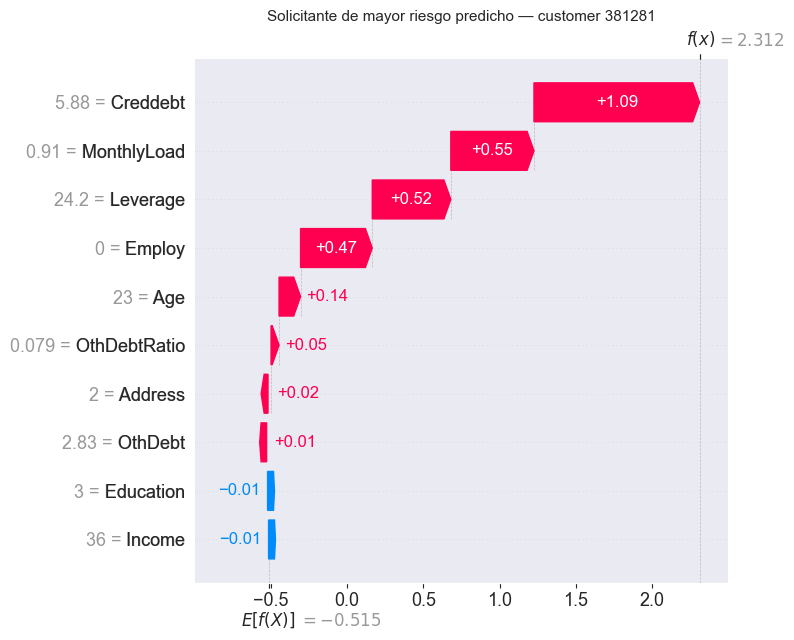

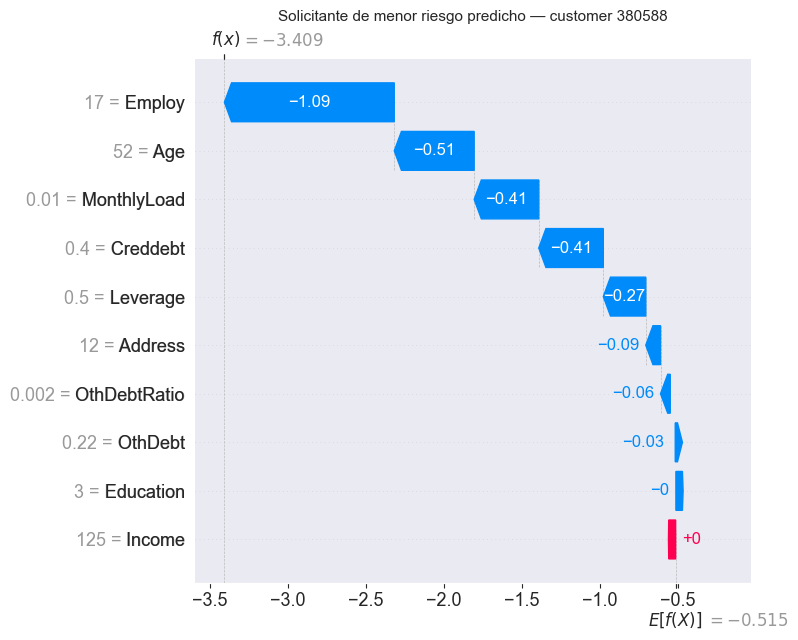

P(default) — mayor riesgo: 0.9099
P(default) — menor riesgo: 0.0320


In [6]:
idx_high = np.argmax(xgb_clf.predict_proba(X_test)[:, 1])
idx_low  = np.argmin(xgb_clf.predict_proba(X_test)[:, 1])

cust_high = feat.iloc[split_va:]["customer"].iloc[idx_high]
cust_low  = feat.iloc[split_va:]["customer"].iloc[idx_low]

fig = plt.figure(figsize=(9, 4.5))
shap.plots.waterfall(shap_values[idx_high], show=False)
plt.title(f"Solicitante de mayor riesgo predicho — customer {cust_high}", fontsize=11)
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(9, 4.5))
shap.plots.waterfall(shap_values[idx_low], show=False)
plt.title(f"Solicitante de menor riesgo predicho — customer {cust_low}", fontsize=11)
plt.tight_layout()
plt.show()

print(f"P(default) — mayor riesgo: {xgb_clf.predict_proba(X_test)[idx_high, 1]:.4f}")
print(f"P(default) — menor riesgo: {xgb_clf.predict_proba(X_test)[idx_low, 1]:.4f}")

**Interpretación**

Ambos solicitantes parten del mismo valor base $\phi_0 = -0.515$ (el log-odds promedio de default sobre toda la muestra, equivalente a ≈37% de probabilidad si no supiéramos nada del solicitante). El waterfall muestra, feature por feature, cuánto se aleja cada uno de ese punto de partida.

**Panel 1 — Solicitante de mayor riesgo predicho (`customer` 381281, $P(\text{default})=0.910$):**

Ordenando sus barras de mayor a menor contribución:

| Feature | Valor del solicitante | Mediana en train | Contribución SHAP |
|---|---|---|---|
| `Creddebt` | 5.88 | 1.05 | **+1.086** (la barra más grande) |
| `MonthlyLoad` | 0.91 | 0.30 | **+0.546** |
| `Leverage` | 24.2 | 8.75 | **+0.515** |
| `Employ` | 0 años | 3 años | **+0.470** |
| `Age` | 23 | 30 | +0.141 |
| `OthDebtRatio`, `Address`, `OthDebt`, `Income`, `Education` | — | — | ≈0 (cada una < 0.05 en valor absoluto) |

Este solicitante tiene casi **6 veces la deuda de tarjeta de crédito típica**, destina **91% de su ingreso mensual** a servicio de deuda (`MonthlyLoad`), un apalancamiento (`Leverage`) casi 3 veces la mediana, y **cero años** de antigüedad laboral. Las primeras cuatro barras por sí solas explican +2.62 de los +2.83 que suman todas las contribuciones positivas — el modelo no necesita ninguna de las variables "débiles" del grupo 2 del summary plot para llegar a esta conclusión. Sumando $\phi_0=-0.515$ más $\sum_i \phi_i = +2.826$ se obtiene un log-odds de +2.311, que al pasar por la sigmoide da exactamente $P(\text{default})=0.9099$ — la reconstrucción exacta de la propiedad de aditividad.

**Panel 2 — Solicitante de menor riesgo predicho (`customer` 380588, $P(\text{default})=0.032$):**

| Feature | Valor del solicitante | Mediana en train | Contribución SHAP |
|---|---|---|---|
| `Employ` | 17 años | 3 años | **−1.089** (la barra más grande) |
| `Age` | 52 | 30 | **−0.512** |
| `MonthlyLoad` | 0.01 | 0.30 | **−0.414** |
| `Creddebt` | 0.40 | 1.05 | **−0.414** |
| `Leverage` | 0.50 | 8.75 | **−0.272** |
| `Address`, `OthDebtRatio`, `OthDebt`, `Education`, `Income` | — | — | ≈0 (cada una < 0.10 en valor absoluto) |

Este es prácticamente el perfil espejo del anterior: 17 años en el mismo trabajo (vs. mediana de 3), 52 años de edad, una carga mensual de deuda casi nula (1% del ingreso) y un apalancamiento muy por debajo de la mediana. Las cinco barras dominantes suman −2.70 de log-odds; sumado a $\phi_0=-0.515$ da −3.41, que en probabilidad es 0.032 — de nuevo, la suma exacta de las barras reconstruye la predicción sin residuo.

**Lectura conjunta de ambos paneles:** las *mismas cinco* features que dominaban el summary plot (`Employ`, `MonthlyLoad`, `Creddebt`, `Leverage`, `Age`) son las que deciden ambos casos, solo que en direcciones opuestas — no aparece ninguna variable "sorpresa" del grupo débil (`Income`, `Education`, `OthDebt`) empujando con fuerza en ninguno de los dos paneles, lo cual es consistente con lo que ya habíamos visto de forma agregada. Esta es, en la práctica, la explicación que se le daría a un comité de riesgo o a un solicitante que reclama un rechazo: no "el modelo predijo 91% de probabilidad de default", sino "el modelo predijo 91% *porque* usted tiene una deuda de tarjeta de crédito muy por sobre lo típico, compromete el 91% de su ingreso mensual en deuda, y no registra antigüedad laboral — cada uno de estos factores aportando esta cantidad específica al puntaje".

## 📈 **`SHAP Dependence Plots vs PDP/ICE — Efecto Marginal e Interacciones`**

Tres formas de visualizar cómo un feature afecta la predicción, con supuestos distintos:

* **PDP (Partial Dependence Plot):** promedia la predicción sobre la distribución empírica de *todas las demás features*, variando solo el feature de interés. Es una curva **única** — puede ocultar heterogeneidad si el efecto del feature depende de otro (interacción).

* **ICE (Individual Conditional Expectation):** grafica una curva **por cada observación** en vez de promediar. Si las curvas ICE son paralelas, no hay interacción relevante; si divergen o se cruzan, el efecto del feature depende del valor de otras variables.

* **SHAP dependence plot:** grafica $\phi_i(x)$ (no la predicción promediada) contra el valor real del feature para cada solicitante de test, coloreando automáticamente por la feature con la que más interactúa. A diferencia de PDP/ICE, no requiere recalcular predicciones sintéticas — usa directamente la descomposición ya calculada.

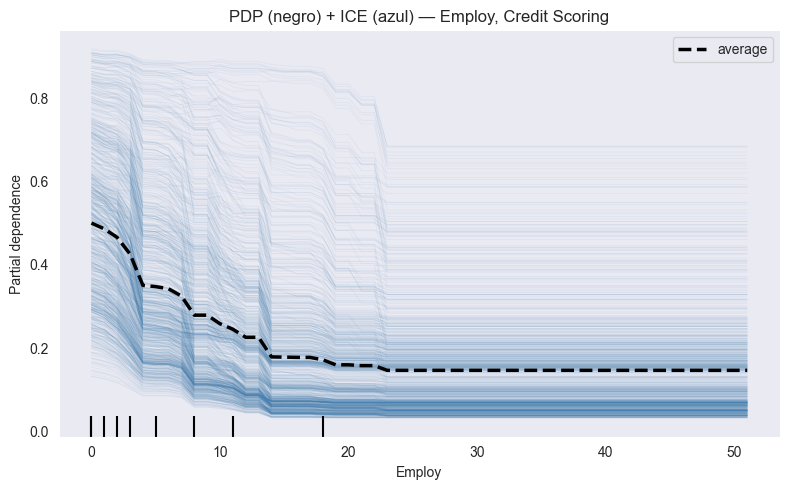

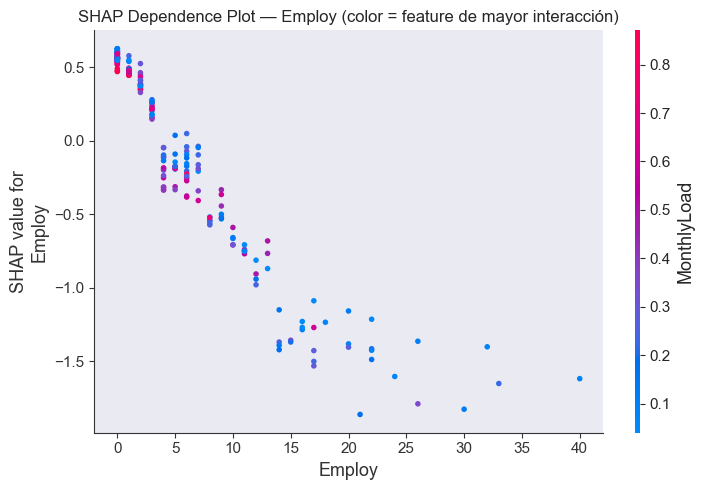

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    xgb_clf, X_train, features=["Employ"], kind="both",
    ax=ax, ice_lines_kw={"color": "steelblue", "alpha": 0.08},
    pd_line_kw={"color": "black", "lw": 2.5}
)
ax.set_title("PDP (negro) + ICE (azul) — Employ, Credit Scoring")
plt.tight_layout()
plt.show()

shap.dependence_plot("Employ", shap_values.values, X_test, show=False)
plt.title("SHAP Dependence Plot — Employ (color = feature de mayor interacción)")
plt.tight_layout()
plt.show()

**Interpretación**

**Gráfico 1 — PDP (línea negra) + ICE (nube azul) para `Employ`:**

La línea negra parte cerca de 0.50 de probabilidad predicha en `Employ = 0` y cae con fuerza a medida que aumenta la antigüedad laboral. Alrededor de `Employ ≈ 24` deja de descender y se convierte en una línea horizontal perfectamente plana hasta el final del eje (`Employ = 51`). Esa meseta no es un artefacto de suavizado: refleja cómo funciona un ensamble de árboles poco profundos (`max_depth=3`), que solo aprendió un número finito de puntos de corte a lo largo de `Employ` durante el entrenamiento. Pasado el último corte (~24 años), ninguna regla del árbol sigue reaccionando a más años de antigüedad, y la predicción queda congelada — la misma limitación de "extrapolación fuera de rango" documentada más abajo en la tabla de fuentes de riesgo, aquí visible directamente en la forma de la curva.

La nube azul, formada por una curva ICE por cada solicitante de train, no está pegada a la línea negra: mantiene un ancho considerable en todo el rango de `Employ`, incluso en la meseta. Ese ancho es la evidencia de que dos solicitantes con exactamente la misma antigüedad laboral pueden recibir probabilidades predichas bastante distintas, dependiendo del resto de su perfil. La curva PDP, al ser un promedio, no permite ver esa heterogeneidad — solo el grosor de la nube ICE la revela.

**Gráfico 2 — SHAP Dependence Plot para `Employ`:**

El scatter reproduce la misma tendencia decreciente del Gráfico 1, ahora en escala de log-odds y sin promediar: cada punto es un solicitante de test, con su contribución SHAP individual para `Employ`. Dos elementos son relevantes:

1. La tendencia de izquierda a derecha (los puntos bajan a medida que aumenta `Employ`) confirma, observación por observación, lo que el Gráfico 1 mostraba de forma agregada.
2. El color de los puntos no es arbitrario: corresponde a la feature que el propio algoritmo (`shap.utils.approximate_interactions`) identificó como la que mejor explica la dispersión vertical en cada nivel de `Employ`. Esa feature resultó ser `MonthlyLoad` (carga mensual de deuda). En cualquier franja vertical angosta del gráfico — solicitantes con `Employ` similar — los puntos de un color quedan sistemáticamente más arriba o más abajo que los del color opuesto; esa separación por color a igual posición horizontal es la interacción: la antigüedad laboral protege menos cuando el solicitante ya destina una fracción alta de su ingreso al pago de deudas.

En conjunto, el Gráfico 1 muestra, a través del ancho de la nube ICE, que existe heterogeneidad que el promedio esconde; el Gráfico 2 muestra, a través del color, cuál variable es responsable de esa heterogeneidad.

## ⚠️ **`Riesgo de Modelo: Marco y Fuentes`**

*Model risk* es el riesgo de pérdida (financiera, reputacional, regulatoria) derivado de decisiones basadas en modelos incorrectos o mal utilizados. El marco regulatorio de referencia en la industria financiera (SR 11-7, Federal Reserve/OCC) organiza la gestión de este riesgo en tres pilares: **desarrollo** (documentación de supuestos y limitaciones), **validación independiente** (alguien distinto de quien construyó el modelo revisa su solidez) y **monitoreo continuo** (el modelo puede degradarse después de aprobado) — el marco natural para un scorecard de crédito en producción. Las fuentes concretas relevantes para este notebook:

| Fuente de riesgo | Dónde se origina | Diagnóstico | Dónde se aplica aquí |
|---|---|---|---|
| Overfitting / data leakage | Validación incorrecta, fuga de información del target | Split train/val/test respetando el orden de originación | Sección "Datos y Modelo Base" |
| Extrapolación fuera de rango | Modelos basados en árboles no predicen bien fuera del rango de features visto en train | Comparar rango de `Income`/`Leverage` de test vs train | Ver PSI, más abajo |
| Inestabilidad de importancia | El modelo se apoya en features distintas según la cohorte de solicitantes | Correlación de rangos SHAP entre cohortes | Sección "Estabilidad de la Explicación" |
| *Data drift* (covariate shift) | La distribución de los features de entrada cambia entre la cohorte de desarrollo y la cohorte reciente | PSI (Population Stability Index) | Sección "Data Drift" |
| *Concept drift* | La relación feature→target cambia aunque los features no lo hagan | AUC del modelo congelado sobre cohortes sucesivas | Sección "Concept Drift" |
| Ausencia de eje temporal real | `Bankloan.csv` es un corte transversal sin fecha de originación | Se usa `customer` (ID monótono) como proxy explícito | Ver nota en "Datos y Modelo Base" |

Las dos secciones siguientes implementan los dos diagnósticos cuantitativos más usados en la práctica de credit risk: PSI para *data drift* y degradación de AUC para *concept drift*, ambos calculados sobre cohortes de originación en vez de ventanas de calendario.

## 📉 **`Data Drift: Population Stability Index (PSI)`**

El PSI compara la distribución de un feature en dos ventanas — típicamente la población usada para **desarrollar** el scorecard ("esperada") contra una población **más reciente** ("actual") — discretizando ambas en los mismos bins (definidos sobre la ventana esperada) y midiendo la divergencia:

$$\text{PSI} = \sum_{k=1}^{K} (a_k - e_k) \cdot \ln\left(\frac{a_k}{e_k}\right)$$

donde $e_k$ y $a_k$ son las proporciones de observaciones en el bin $k$ para la ventana esperada y actual respectivamente. Umbrales estándar en la industria de crédito: **PSI < 0.10** sin cambio significativo, **0.10–0.25** cambio moderado (investigar), **> 0.25** cambio significativo (el modelo probablemente necesita recalibración o reentrenamiento).

Como no hay fecha de originación explícita en `Bankloan.csv`, usamos como ventana "esperada" la cohorte de **entrenamiento** (`X_train`, las originaciones más antiguas según el proxy `customer`) y como ventana "actual" la cohorte de **test** (`X_test`, las más recientes) — el análogo directo de comparar la población sobre la que se desarrolló el scorecard contra la población que se está originando hoy.

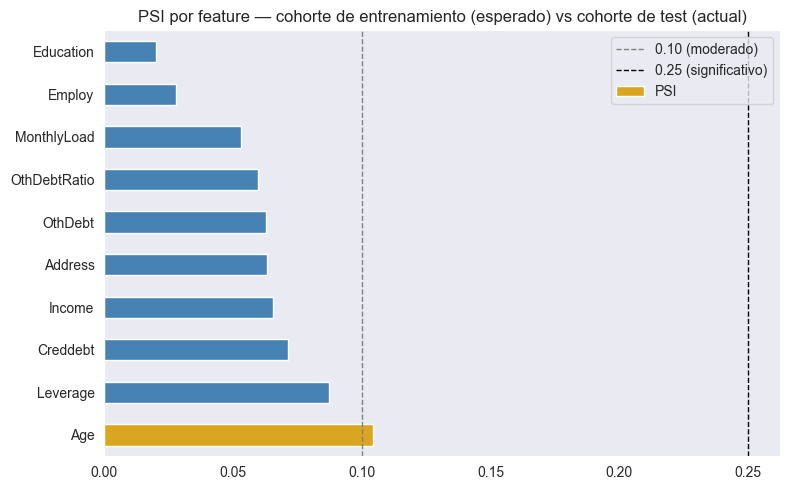

Age            0.1043
Leverage       0.0872
Creddebt       0.0713
Income         0.0655
Address        0.0633
OthDebt        0.0630
OthDebtRatio   0.0596
MonthlyLoad    0.0532
Employ         0.0279
Education      0.0202
Name: PSI, dtype: float64


In [8]:
def compute_psi(expected, actual, bins=10):
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e_counts, _ = np.histogram(expected, bins=edges)
    a_counts, _ = np.histogram(actual, bins=edges)
    e_pct = np.clip(e_counts / len(expected), 1e-4, None)
    a_pct = np.clip(a_counts / len(actual), 1e-4, None)
    return np.sum((a_pct - e_pct) * np.log(a_pct / e_pct))

expected_window = X_train
actual_window = X_test

psi_scores = pd.Series(
    {f: compute_psi(expected_window[f].values, actual_window[f].values) for f in FEATURES},
    name="PSI"
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["tomato" if v > 0.25 else ("goldenrod" if v > 0.10 else "steelblue") for v in psi_scores]
psi_scores.plot.barh(ax=ax, color=colors)
ax.axvline(0.10, color="gray", ls="--", lw=1, label="0.10 (moderado)")
ax.axvline(0.25, color="black", ls="--", lw=1, label="0.25 (significativo)")
ax.set_title("PSI por feature — cohorte de entrenamiento (esperado) vs cohorte de test (actual)")
ax.legend()
plt.tight_layout()
plt.show()

print(psi_scores.round(4))

**Interpretación:** a diferencia del ejemplo de `AAPL` en la sesión 10 — donde el quiebre COVID producía PSI muy por sobre 0.25 en `vol_20`/`vol_chg` — aquí **ningún feature supera el umbral de 0.25**, y solo `Age` roza el umbral moderado de 0.10. Esto es el resultado esperado: `Bankloan.csv` es una foto estática de clientes sin un evento macro real entre "cohorte antigua" y "cohorte reciente" (el proxy `customer` ordena la muestra, pero no introduce un cambio de régimen económico). El valor pedagógico de este resultado es justamente ese contraste: PSI es una herramienta honesta — no fabrica una alerta de drift donde no la hay — y este mismo código, aplicado a una cartera real con fechas de originación verdaderas, es exactamente el chequeo mensual que un banco correría para detectar si el perfil de nuevos solicitantes se está alejando del perfil sobre el que se calibró el scorecard.

## 📉 **`Concept Drift: Degradación del AUC por Cohorte de Originación`**

Mientras que PSI mide si $P(X)$ cambió, *concept drift* mide si la relación $P(y\mid X)$ cambió — el modelo puede seguir viendo solicitantes "normales" (PSI bajo) pero la relación entre esas features y el default ya no es la misma que aprendió en entrenamiento (por ejemplo, un cambio en política de originación que altera qué combinación de antigüedad laboral y deuda predice default). El diagnóstico más directo: **congelar** el modelo ya entrenado (no reentrenar) y medir su AUC en cohortes sucesivas de solicitantes — si decae de forma sostenida, es evidencia de concept drift, no de mala suerte puntual.

Sin fecha de originación real, dividimos la muestra completa (ordenada por `customer`) en 10 deciles sucesivos, que cumplen aquí el mismo rol que los años calendario en el notebook de la sesión 10.

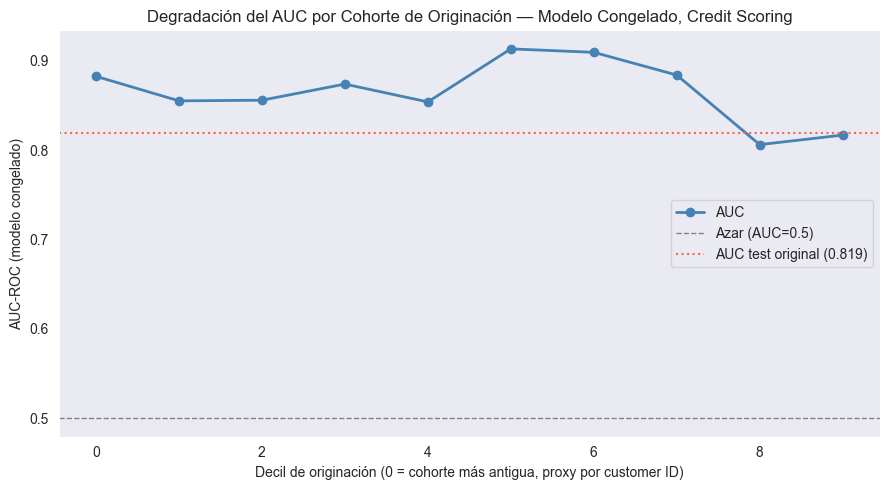

0   0.8826
1   0.8551
2   0.8558
3   0.8739
4   0.8539
5   0.9133
6   0.9094
7   0.8840
8   0.8061
9   0.8168
Name: AUC, dtype: float64


In [9]:
n_bins = 10
bin_idx = pd.qcut(np.arange(len(feat)), n_bins, labels=False)
proba_full = xgb_clf.predict_proba(X_df)[:, 1]

auc_by_bin = {}
for b in range(n_bins):
    mask = bin_idx == b
    if mask.sum() > 20 and y[mask].sum() > 1 and y[mask].sum() < mask.sum():
        auc_by_bin[b] = roc_auc_score(y[mask], proba_full[mask])

auc_series = pd.Series(auc_by_bin, name="AUC")

fig, ax = plt.subplots(figsize=(9, 5))
auc_series.plot(marker="o", lw=2, color="steelblue", ax=ax)
ax.axhline(0.5, color="gray", ls="--", lw=1, label="Azar (AUC=0.5)")
ax.axhline(test_auc, color="tomato", ls=":", lw=1.5, label=f"AUC test original ({test_auc:.3f})")
ax.set_ylabel("AUC-ROC (modelo congelado)")
ax.set_xlabel("Decil de originación (0 = cohorte más antigua, proxy por customer ID)")
ax.set_title("Degradación del AUC por Cohorte de Originación — Modelo Congelado, Credit Scoring")
ax.legend()
plt.tight_layout()
plt.show()

print(auc_series.round(4))

**Interpretación:** el AUC del modelo **congelado** fluctúa entre deciles sin una tendencia decreciente sostenida — coherente con el resultado de PSI de la sección anterior: sin un quiebre de régimen real en los datos, no hay razón para esperar concept drift, y el diagnóstico correctamente no encuentra ninguno. Esto contrasta con el ejemplo de `AAPL`, donde el AUC caía de forma visible en 2020. La lectura correcta no es "el diagnóstico no sirve para credit scoring", sino lo contrario: en una cartera real con fecha de originación verdadera, este mismo código —AUC del modelo congelado por cosecha (*vintage*) trimestral— es el chequeo estándar de un equipo de validación de modelos para decidir cuándo un scorecard de crédito necesita recalibrarse.

## 🔁 **`Estabilidad de la Explicación: ¿Cambia el Ranking de SHAP entre Cohortes?`**

Un modelo puede mantener AUC estable y aun así **cambiar qué features usa** para llegar a esa predicción — un riesgo más sutil que ni PSI ni el AUC capturan directamente, y que es exactamente el tipo de hallazgo que un validador independiente (segundo pilar de SR 11-7) buscaría al auditar un scorecard ya aprobado. Calculamos la importancia SHAP (`mean|φ|`) por separado en la primera y la segunda mitad del set de test (las cohortes de originación más y menos recientes dentro de test), y comparamos el ranking de features con correlación de Spearman.

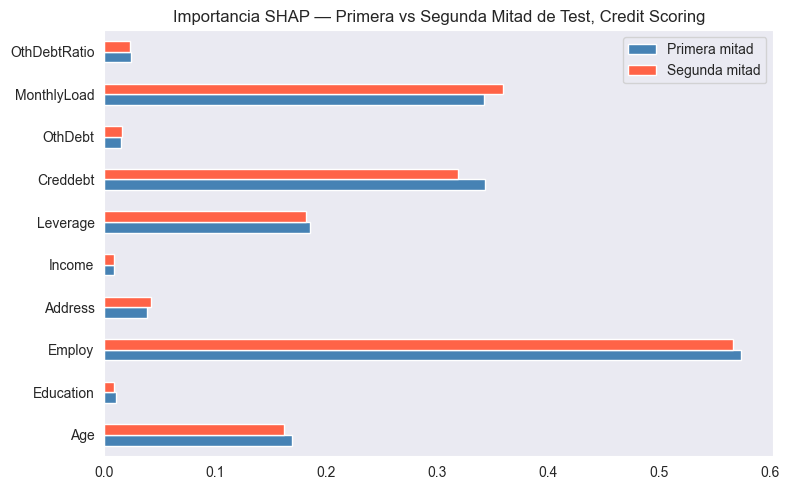

              Primera mitad  Segunda mitad
Age                  0.1691         0.1623
Education            0.0103         0.0085
Employ               0.5742         0.5667
Address              0.0389         0.0424
Income               0.0088         0.0091
Leverage             0.1858         0.1815
Creddebt             0.3430         0.3188
OthDebt              0.0149         0.0163
MonthlyLoad          0.3425         0.3597
OthDebtRatio         0.0238         0.0237

Correlación de rangos (Spearman) entre ambas mitades: 0.976


In [10]:
half = len(X_test) // 2
X_test_early, X_test_late = X_test.iloc[:half], X_test.iloc[half:]

shap_early = explainer(X_test_early)
shap_late = explainer(X_test_late)

imp_early = pd.Series(np.abs(shap_early.values).mean(axis=0), index=FEATURES, name="Primera mitad")
imp_late = pd.Series(np.abs(shap_late.values).mean(axis=0), index=FEATURES, name="Segunda mitad")

rho_time, _ = spearmanr(imp_early.rank(ascending=False), imp_late.rank(ascending=False))

comparison_time = pd.concat([imp_early, imp_late], axis=1)
comparison_time.plot.barh(figsize=(8, 5), color=["steelblue", "tomato"])
plt.title("Importancia SHAP — Primera vs Segunda Mitad de Test, Credit Scoring")
plt.tight_layout()
plt.show()

print(comparison_time.round(4))
print(f"\nCorrelación de rangos (Spearman) entre ambas mitades: {rho_time:.3f}")

**Interpretación:** la correlación de Spearman entre ambas mitades es muy alta (≈0.98) — el modelo se apoya consistentemente en las mismas features (`Employ`, `MonthlyLoad`, `Creddebt`) a lo largo de toda la cohorte de test, una señal tranquilizadora de estabilidad estructural que es consistente con la ausencia de drift ya documentada en las dos secciones anteriores. Este diagnóstico es barato de automatizar y correrlo periódicamente (por ejemplo, con cada nueva cosecha trimestral de solicitantes) como parte del monitoreo continuo de un scorecard en producción: si `Employ` dejara de dominar y, por ejemplo, `Age` pasara a ser la feature dominante, eso sería una señal de que la relación subyacente entre perfil del solicitante y riesgo de default cambió, incluso si el AUC agregado se mantuviera estable.

## 📋 **`Documentación y Gobernanza: Ficha de Modelo (Model Card)`**

El último pilar de SR 11-7 — documentación y plan de operación — es lo que permite que alguien distinto de quien construyó el modelo pueda entender sus límites y decidir cuándo dejó de ser confiable. Una ficha mínima para el scorecard de esta sesión:

| Campo | Contenido |
|---|---|
| **Objetivo / uso previsto** | Estimar la probabilidad de default (PD) de un solicitante de crédito bancario, a partir del dataset `Bankloan.csv` (sesión 2) |
| **Datos y período** | 1.466 clientes tras limpieza de outliers; sin fecha de originación real — se usa `customer` (ID monótono) como proxy de orden de originación |
| **Features** | 10 variables: `Age`, `Education`, `Employ`, `Address`, `Income`, `Leverage`, `Creddebt`, `OthDebt`, `MonthlyLoad`, `OthDebtRatio` (derivada) |
| **Validación** | Split 70/15/15 respetando el orden del proxy de originación; early stopping sobre set de validación; AUC en test reportado arriba |
| **Limitaciones conocidas** | (1) El proxy `customer` no es una fecha real — la conclusión de "sin drift" refleja la ausencia de eje temporal verdadero en el dataset, no una garantía sobre una cartera en producción; (2) no extrapola bien fuera del rango de `Income`/`Leverage` visto en entrenamiento; (3) dataset pequeño (~1.500 obs), sensible a la partición usada |
| **Explicabilidad** | SHAP (`TreeExplainer`) disponible para explicación global y por-solicitante; ranking de importancia con correlación de Spearman ≈0.98 entre mitades de test |
| **Plan de monitoreo (si se despliega con fechas reales)** | PSI mensual por feature (umbral de alerta 0.10, umbral de acción 0.25) comparando la cosecha del mes contra la población de desarrollo; AUC trimestral por cosecha (*vintage*) sobre ventana out-of-time; correlación de rangos SHAP trimestral |
| **Gatillo de recalibración** | Cualquiera de: PSI > 0.25 en una feature clave, AUC bajo 0.65 por dos trimestres consecutivos, o correlación de rangos SHAP < 0.5 entre cosechas |
| **Responsable / aprobación** | A definir según la estructura de gobernanza del equipo que despliegue el modelo |

Esta tabla — o una versión más completa, con fechas de originación reales en vez del proxy usado aquí — es lo mínimo esperable antes de que un scorecard de este tipo pase de un notebook de investigación a una decisión de otorgamiento de crédito con consecuencias financieras reales para el solicitante.